# 📊 Análisis de KPIs de E-commerce

En este proyecto se analizan los principales indicadores clave (KPIs) de un negocio de e-commerce con el objetivo de identificar patrones de venta, comportamiento del cliente y oportunidades de mejora en la toma de decisiones.

**Autor:** Joan Ramón Valdez Castillo  

# Contexto

Una empresa de e-commerce busca entender su desempeño operativo y financiero.  
Se cuenta con datos de ventas que incluyen productos, precios y cantidades.

El objetivo es transformar estos datos en información útil para la toma de decisiones estratégicas.

# Objetivos

Analizar los principales KPIs del negocio para:

- Evaluar el desempeño en ventas
- Identificar las categorías más rentables
- Detectar patrones por ciudad
- Proponer oportunidades de mejora

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

products = pd.read_excel("ecommerce_kpi_dataset.xlsx", sheet_name="products")
customers = pd.read_excel("ecommerce_kpi_dataset.xlsx", sheet_name="customers")
orders = pd.read_excel("ecommerce_kpi_dataset.xlsx", sheet_name="orders")
order_items = pd.read_excel("ecommerce_kpi_dataset.xlsx", sheet_name="order_items")
sessions = pd.read_excel("ecommerce_kpi_dataset.xlsx", sheet_name="sessions")
marketing = pd.read_excel("ecommerce_kpi_dataset.xlsx", sheet_name="marketing")

In [4]:
order_items

,order_id,product_id,quantity,unit_price
0,1,6,3,113.23
1,2,4,2,48.03
2,2,25,2,387.67
3,3,25,2,387.67
4,3,27,2,193.16
...,...,...,...,...
5031,1999,19,2,66.79
5032,1999,9,2,212.66
5033,1999,38,2,118.38
5034,2000,40,1,137.53


Renombro las columnas para una mejor lectura

In [5]:
names= {"order_id":"ID Orden", "product_id": "ID Producto", "quantity":"Cantidad", "unit_price":"Precio de unidad"}

Les cambio el nombre definitivamente con inplace

In [6]:
order_items.rename(columns=names, inplace=True)

In [7]:
order_items

,ID Orden,ID Producto,Cantidad,Precio de unidad
0,1,6,3,113.23
1,2,4,2,48.03
2,2,25,2,387.67
3,3,25,2,387.67
4,3,27,2,193.16
...,...,...,...,...
5031,1999,19,2,66.79
5032,1999,9,2,212.66
5033,1999,38,2,118.38
5034,2000,40,1,137.53


# KPI 1: Ganancia Total

Con esto calculo la Ganancia total, multiplicando la cantidad por el precio de
cada unidad

In [8]:
order_items["Ganancia"] = order_items["Cantidad"] * order_items["Precio de unidad"]

Sumo la columna de ganancia para ver el total

In [9]:
ganancia_total = order_items["Ganancia"].sum()
print(f"La ganancia total es de {ganancia_total}")

La ganancia total es de 2264223.83


# KPI 2: Número de pedidos

In [10]:
orders

,order_id,customer_id,order_date,channel
0,1,202,2024-10-30,Marketplace
1,2,220,2024-03-10,App
2,3,109,2024-08-20,App
3,4,10,2024-10-03,Web
4,5,127,2024-04-12,Web
...,...,...,...,...
1995,1996,288,2024-05-06,Web
1996,1997,9,2024-08-28,Web
1997,1998,209,2024-01-03,Marketplace
1998,1999,31,2024-08-08,Web


Limpio un poco para que se entiendan mejor las columnas

In [11]:
names2= {"order_id":"ID Orden", "customer_id":"ID de Cliente","order_date":"Fecha de Orden", "channel":"Canal"}
orders.rename(columns=names2, inplace=True)

Cuento el numero total de pedidos con nunique

In [12]:
total_ordenes = orders["ID Orden"].nunique()

print(f"El total de pedidos fueron: {total_ordenes}")

El total de pedidos fueron: 2000


Pero una cosa son los pedidos totales y otras las cantidades que se pidieron en
cada uno de los pedidos. Lo calculo a continuación:

In [13]:
total = order_items["Cantidad"].sum()
print(f"El total de productos vendidos fue: {total}")

El total de productos vendidos fue: 10084


# KPI 3: Ticket promedio (AOV)

Calculo el ticket promedio total con el total de ordenes y ganancia total.


In [14]:
AOV = ganancia_total / total_ordenes
print(f"El ticket promedio tiene un valor de: {AOV:.2f}")

El ticket promedio tiene un valor de: 1132.11


# KPI 3.1: EXTRA, PROMEDIO DE PRODUCTOS POR PEDIDO

Y aqui el promedio de productos por pedido

In [15]:
AOV2 = total / total_ordenes
print(f"En promedio, cada pedido contiene {round(AOV2,0)} productos.")

En promedio, cada pedido contiene 5.0 productos.


# KPI 4: Crecimiento mensual

Paso primero la columna de Fecha a una de tipo fecha para que se puedan
aplicar las funciones de esa índole.

In [16]:
orders["Fecha de Orden"] = pd.to_datetime(orders["Fecha de Orden"])

Uno los dataframes orders y order_item por la columna en común "ID Orden".

In [17]:
venta = orders.merge(order_items, on="ID Orden")

In [18]:
venta

,ID Orden,ID de Cliente,Fecha de Orden,Canal,ID Producto,Cantidad,Precio de unidad,Ganancia
0,1,202,2024-10-30,Marketplace,6,3,113.23,339.69
1,2,220,2024-03-10,App,4,2,48.03,96.06
2,2,220,2024-03-10,App,25,2,387.67,775.34
3,3,109,2024-08-20,App,25,2,387.67,775.34
4,3,109,2024-08-20,App,27,2,193.16,386.32
...,...,...,...,...,...,...,...,...
5031,1999,31,2024-08-08,Web,19,2,66.79,133.58
5032,1999,31,2024-08-08,Web,9,2,212.66,425.32
5033,1999,31,2024-08-08,Web,38,2,118.38,236.76
5034,2000,297,2024-05-27,App,40,1,137.53,137.53


## Ventas Mensuales

Las ventas mensuales permiten observar el desempeño del negocio a lo largo del tiempo.

Para calcularlas, se agruparon los datos por mes a partir de la fecha de orden y se sumaron las ganancias totales de cada periodo.

Este análisis permite identificar tendencias, estacionalidad y meses con mayor o menor rendimiento.

In [19]:
# Crear columna mes
venta["Mes"] = venta["Fecha de Orden"].dt.to_period("M")

# Ventas por mes
venta_mensual = venta.groupby("Mes")["Ganancia"].sum()

In [20]:
venta_mensual

,Ganancia
Mes,
2024-01,204878.23
2024-02,207893.86
2024-03,166448.26
2024-04,170095.26
2024-05,208956.38
2024-06,197166.98
2024-07,176002.21
2024-08,174732.12
2024-09,209588.20


## Crecimiento Mensual

El crecimiento mensual mide la variación porcentual de las ventas respecto al mes anterior.

Se calculó utilizando el cambio porcentual (pct_change) sobre las ventas mensuales.

Valores positivos indican crecimiento, mientras que valores negativos reflejan una disminución en las ventas.

Este KPI es clave para detectar caídas importantes o periodos de aceleración en el negocio.

In [21]:
crecimiento_mensual = venta_mensual.pct_change() * 100

crecimiento_mensual

,Ganancia
Mes,
2024-01,NaN
2024-02,1.471913
2024-03,-19.935942
2024-04,2.191071
2024-05,22.846680
2024-06,-5.642039
2024-07,-10.734439
2024-08,-0.721633
2024-09,19.948296


# KPI 5: Ventas por *canal*

Este KPI evalúa el desempeño de los distintos canales de venta (por ejemplo, web o aplicación).

Se agruparon las ventas por canal y se calculó la ganancia total para cada uno.

El análisis permite identificar qué canal es más rentable y dónde enfocar los esfuerzos de marketing y optimización.

In [22]:
ventas_canal = venta.groupby("Canal")["Ganancia"].sum()
ventas_canal

,Ganancia
Canal,
App,747997.16
Marketplace,760319.87
Web,755906.80


# KPI 6: Productos más vendidos

El análisis de productos más vendidos permite identificar qué artículos generan mayor volumen de ventas.

Para ello, se agruparon los datos por producto y se sumó la cantidad total vendida.

Este indicador es útil para la gestión de inventario, estrategias de promoción y toma de decisiones comerciales.

In [23]:
top_productos = venta.groupby("ID Producto")["Cantidad"].sum().sort_values(ascending=False).head(10)
top_productos

,Cantidad
ID Producto,
25,304
5,303
31,303
6,292
29,283
21,279
10,278
39,277
37,269


# KPI 7: Categorías más vendidas

Este análisis es importante para conocer de todas las categorías que manejamos
en stock, cuales son las que más vendemos. Para así, tomar decisiones en cada
departamento correspondiente.

In [24]:
venta = venta.merge(products, left_on="ID Producto", right_on="product_id")
ventas_categoria = venta.groupby("category")["Ganancia"].sum().sort_values(ascending=False)
ventas_categoria

,Ganancia
category,
Sports,598116.47
Electronics,589282.98
Home,510086.14
Books,317614.87
Clothing,249123.37


Ahora analicemos esto. Veamos cual es diferencia porcentual a la categoría con
más ganancia. Es decir, con la de Sports.

In [25]:
ganancia_categoria = venta.groupby("category")["Ganancia"].sum()

top = ganancia_categoria.max()

diferencia_pct = ((ganancia_categoria / top) - 1) * 100

diferencia_pct.sort_values(ascending=False)

,Ganancia
category,
Sports,0.000000
Electronics,-1.476885
Home,-14.717924
Books,-46.897488
Clothing,-58.348686


De esto se concluye que aunque deportes fue la que tuvo más ganancias, la de electrónica solo se distanció un 1.47%. Por lo que es muy similar.

Las categorías de Sports, Electronics y Home concentran gran parte del negocio. Su diferencia es muy acortada con respecto a Books y Clothing.

# Conversion Rate

De todos los que visitaron nuestra web, ¿quienes SÍ compraron?

In [26]:
total_visitas = sessions["visits"].sum()
tasa_conversion = (total_ordenes / total_visitas) * 100
print("Tasa de conversión:", round(tasa_conversion,2), "%")

Tasa de conversión: 0.94 %


La tasa de conversión es de 0.94%, lo que indica que aproximadamente 1 de cada 100 visitantes realiza una compra.

Esto puede señalar oportunidades de optimización en la experiencia del usuario, el proceso de compra o las estrategias de marketing.

# Clientes recurrentes

In [27]:
orders

,ID Orden,ID de Cliente,Fecha de Orden,Canal
0,1,202,2024-10-30,Marketplace
1,2,220,2024-03-10,App
2,3,109,2024-08-20,App
3,4,10,2024-10-03,Web
4,5,127,2024-04-12,Web
...,...,...,...,...
1995,1996,288,2024-05-06,Web
1996,1997,9,2024-08-28,Web
1997,1998,209,2024-01-03,Marketplace
1998,1999,31,2024-08-08,Web


In [28]:
ordenes_por_cliente = orders.groupby("ID de Cliente")["Canal"].count().sort_values(ascending=False)

In [29]:
ordenes_por_cliente.head()

,Canal
ID de Cliente,
251,14
133,14
235,14
69,13
255,13


Considerare más de 5 compras como clientes recurrentes pero esto es subjetivo a quien lo estudia.

In [30]:
clientes_recurrentes = (ordenes_por_cliente > 5).sum()
print("Clientes recurrentes:", clientes_recurrentes)

Clientes recurrentes: 197


# Ticket promedio por cliente

Primero calculo la ganancia por cliente

In [31]:
ganancia_por_cliente = venta.groupby("ID de Cliente")["Ganancia"].sum()
ganancia_por_cliente.head().sort_values(ascending=False)

,Ganancia
ID de Cliente,
5,12525.87
1,10223.21
4,6166.79
3,5942.67
2,2900.77


Con esto vemos que el Cliente con ID No. 5, es el que mayor ganancia tuvo.

Ahora, calculo el valor de la ganancia promedio por cliente.

In [32]:
ticket_promedio_cliente = ganancia_por_cliente.mean()
print("Ticket promedio por cliente:", round(ticket_promedio_cliente,2))

Ticket promedio por cliente: 7547.41


No fue posible calcular crecimiento anual debido a que el dataset contiene información de un solo año. En su lugar, se analizó el crecimiento mensual para identificar tendencias.

# Ventas por ciudad

In [33]:
customers

,customer_id,city,signup_date
0,1,Guadalajara,2024-05-25
1,2,Monterrey,2024-02-24
2,3,Puebla,2024-04-11
3,4,Puebla,2024-02-06
4,5,Monterrey,2024-02-05
...,...,...,...
295,296,Monterrey,2024-06-20
296,297,Puebla,2024-07-04
297,298,Guadalajara,2024-04-29
298,299,Guadalajara,2024-06-08


In [34]:
names3= {"customer_id":"ID de Cliente", "city":"Ciudad", "signup_date":"Fecha de inicio de sesión"}
customers.rename(columns=names3, inplace=True)

In [35]:
customers

,ID de Cliente,Ciudad,Fecha de inicio de sesión
0,1,Guadalajara,2024-05-25
1,2,Monterrey,2024-02-24
2,3,Puebla,2024-04-11
3,4,Puebla,2024-02-06
4,5,Monterrey,2024-02-05
...,...,...,...
295,296,Monterrey,2024-06-20
296,297,Puebla,2024-07-04
297,298,Guadalajara,2024-04-29
298,299,Guadalajara,2024-06-08


In [36]:
ventas_ciudad= venta.merge(customers, on="ID de Cliente")
venta_por_ciudad= ventas_ciudad.groupby("Ciudad")["Ganancia"].sum().sort_values(ascending=False)
venta_por_ciudad

,Ganancia
Ciudad,
Guadalajara,501082.85
Monterrey,496994.55
Querétaro,457409.55
Puebla,439621.71
CDMX,369115.17


In [37]:
top = venta_por_ciudad.max()

diferencia_pct2 = ((venta_por_ciudad / top) - 1) * 100

diferencia_pct2.sort_values(ascending=False)

,Ganancia
Ciudad,
Guadalajara,0.000000
Monterrey,-0.815893
Querétaro,-8.715784
Puebla,-12.265664
CDMX,-26.336499


Observamos que Guadalajara es la ciudad con mayor ganancia. No se concentra todo ahí, Monterrey se aleja a tan solo un 0.81% y Queretaro de un 8.7%.

Puebla y la CDMX son los que se alejan un poco más, con un 12.26% y 26.33% respectivamente.

Algo clave es que el norte del país son los que mas consumen. El centro del país se queda un poco resagado.

## Participación de cada estado



In [38]:
venta_por_ciudad2 = venta_por_ciudad.to_frame()
venta_por_ciudad2["Participacion (%)"] = venta_por_ciudad2["Ganancia"] / venta_por_ciudad2["Ganancia"].sum() * 100
venta_por_ciudad2

,Ganancia,Participacion (%)
Ciudad,,
Guadalajara,501082.85,22.130447
Monterrey,496994.55,21.949886
Querétaro,457409.55,20.201605
Puebla,439621.71,19.416000
CDMX,369115.17,16.302062


Se calculó la participación porcentual de cada ciudad respecto al total de ventas, con el objetivo de identificar la concentración geográfica de los ingresos. Podemos decir que las 5 ciudades aportan de manera similar, sin embargo, la CDMX se quedó un poco resagada con un 6% respecto de Guadalajara (la ciudad que aporta más).

# Ticket promedio por ciudad

In [39]:
ticket_ciudad = ventas_ciudad.groupby("Ciudad").agg({
    "Ganancia": "sum",
    "ID Orden": "nunique"
})

ticket_ciudad["Ticket Promedio"] = ticket_ciudad["Ganancia"] / ticket_ciudad["ID Orden"]
ticket_ciudad.sort_values("Ticket Promedio", ascending=False)

,Ganancia,ID Orden,Ticket Promedio
Ciudad,,,
Monterrey,496994.55,413,1203.376634
Guadalajara,501082.85,429,1168.025291
Querétaro,457409.55,400,1143.523875
Puebla,439621.71,412,1067.042985
CDMX,369115.17,346,1066.806850


Cuánto gasta en promedio un cliente en cada ciudad. Algunas ciudades pueden tener menos ventas pero tickets más altos (clientes más valiosos).

# Productos más vendidos por ciudad

In [40]:
top_ciudad_producto = ventas_ciudad.groupby(["Ciudad", "ID Producto"])["Cantidad"].sum().sort_values(ascending=False)
top_ciudad_producto.head(10)

,,Cantidad
Ciudad,ID Producto,
Monterrey,31,85
Guadalajara,21,77
Puebla,5,77
Guadalajara,22,76
Querétaro,14,73
Monterrey,29,72
Guadalajara,31,72
Puebla,32,72
Monterrey,10,71


Ahora, los últimos

In [41]:
top_ciudad_producto.tail()

Ciudad     ID Producto
CDMX       7              29
           40             29
Puebla     28             28
Querétaro  15             26
CDMX       27             20
Name: Cantidad, dtype: int64

De los 10 productos más vendidos, Monterrey tiene 4, incluso el más vendido.
Guadalajara con 3, Puebla con 2 y Querétaro con 1.

Se vende más cantidad de productos en el norte. Monterrey tiene el más vendido: el producto 31. Mientras que el 27 es el que menos se vende en general en la CDMX con 20 unidades.

# En cada ciudad, ¿por cual canal se ganó más?

In [42]:
ventas_ciudad_canal = ventas_ciudad.groupby(["Ciudad", "Canal"])["Ganancia"].sum()
ventas_ciudad_canal

Ciudad       Canal      
CDMX         App            113992.15
             Marketplace    116277.90
             Web            138845.12
Guadalajara  App            167010.31
             Marketplace    156390.38
             Web            177682.16
Monterrey    App            171982.27
             Marketplace    164638.28
             Web            160374.00
Puebla       App            148797.75
             Marketplace    149358.11
             Web            141465.85
Querétaro    App            146214.68
             Marketplace    173655.20
             Web            137539.67
Name: Ganancia, dtype: float64

Aqui se obtuvieron las ganancias de cada ciudad en cada canal. Hacer un reporte de cada parametro es tardado, por lo que mejor sería observalo en la gráfica.

In [43]:
ventas_final = venta.merge(customers, on="ID de Cliente")
ventas_final

,ID Orden,ID de Cliente,Fecha de Orden,Canal,ID Producto,Cantidad,Precio de unidad,Ganancia,Mes,product_id,product_name,category,price,Ciudad,Fecha de inicio de sesión
0,1,202,2024-10-30,Marketplace,6,3,113.23,339.69,2024-10,6,Product_6,Electronics,113.23,Querétaro,2024-05-10
1,2,220,2024-03-10,App,4,2,48.03,96.06,2024-03,4,Product_4,Books,48.03,Puebla,2024-06-22
2,2,220,2024-03-10,App,25,2,387.67,775.34,2024-03,25,Product_25,Home,387.67,Puebla,2024-06-22
3,3,109,2024-08-20,App,25,2,387.67,775.34,2024-08,25,Product_25,Home,387.67,Monterrey,2024-01-15
4,3,109,2024-08-20,App,27,2,193.16,386.32,2024-08,27,Product_27,Electronics,193.16,Monterrey,2024-01-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5031,1999,31,2024-08-08,Web,19,2,66.79,133.58,2024-08,19,Product_19,Books,66.79,Guadalajara,2024-05-09
5032,1999,31,2024-08-08,Web,9,2,212.66,425.32,2024-08,9,Product_9,Books,212.66,Guadalajara,2024-05-09
5033,1999,31,2024-08-08,Web,38,2,118.38,236.76,2024-08,38,Product_38,Electronics,118.38,Guadalajara,2024-05-09
5034,2000,297,2024-05-27,App,40,1,137.53,137.53,2024-05,40,Product_40,Clothing,137.53,Puebla,2024-07-04


In [44]:
venta_city_category= ventas_final.groupby(["Ciudad", "category"]).agg({"Cantidad": "sum","Ganancia":"sum"})
venta_city_category

Cantidad   Ganancia
Ciudad      category                        
CDMX        Books             321   56115.78
            Clothing          275   41435.28
            Electronics       344   81822.10
            Home              279   85275.49
            Sports            459  104466.52
Guadalajara Books             366   74344.31
            Clothing          358   53566.19
            Electronics       573  129565.75
            Home              344  108469.26
            Sports            593  135137.34
Monterrey   Books             351   64131.06
            Clothing          384   59077.23
            Electronics       572  133618.10
            Home              326  108782.98
            Sports            553  131385.18
Puebla      Books             361   67352.01
            Clothing          332   39787.83
            Electronics       527  123418.39
            Home              290   95688.27
            Sports            467  113375.21
Querétaro   Books             308   55671.71
            Clothing          389   55256.84
            Electronics       508  120858.64
            Home              327  111870.14
            Sports            477  113752.22

Para mejorar las gráficas, partamosla en dos. Una de pura ganancia.

In [45]:
venta_city_category2= ventas_final.groupby(["Ciudad", "category"])["Ganancia"].sum()
venta_city_category2

Ciudad       category   
CDMX         Books           56115.78
             Clothing        41435.28
             Electronics     81822.10
             Home            85275.49
             Sports         104466.52
Guadalajara  Books           74344.31
             Clothing        53566.19
             Electronics    129565.75
             Home           108469.26
             Sports         135137.34
Monterrey    Books           64131.06
             Clothing        59077.23
             Electronics    133618.10
             Home           108782.98
             Sports         131385.18
Puebla       Books           67352.01
             Clothing        39787.83
             Electronics    123418.39
             Home            95688.27
             Sports         113375.21
Querétaro    Books           55671.71
             Clothing        55256.84
             Electronics    120858.64
             Home           111870.14
             Sports         113752.22
Name: Ganancia, dtype: float64

Y otro de las cantidades que compraron de cada categoría

In [46]:
venta_city_category3= ventas_final.groupby(["Ciudad", "category"])["Cantidad"].sum()
venta_city_category3

Ciudad       category   
CDMX         Books          321
             Clothing       275
             Electronics    344
             Home           279
             Sports         459
Guadalajara  Books          366
             Clothing       358
             Electronics    573
             Home           344
             Sports         593
Monterrey    Books          351
             Clothing       384
             Electronics    572
             Home           326
             Sports         553
Puebla       Books          361
             Clothing       332
             Electronics    527
             Home           290
             Sports         467
Querétaro    Books          308
             Clothing       389
             Electronics    508
             Home           327
             Sports         477
Name: Cantidad, dtype: int64

# Gráficas

## Comportamiento mensual

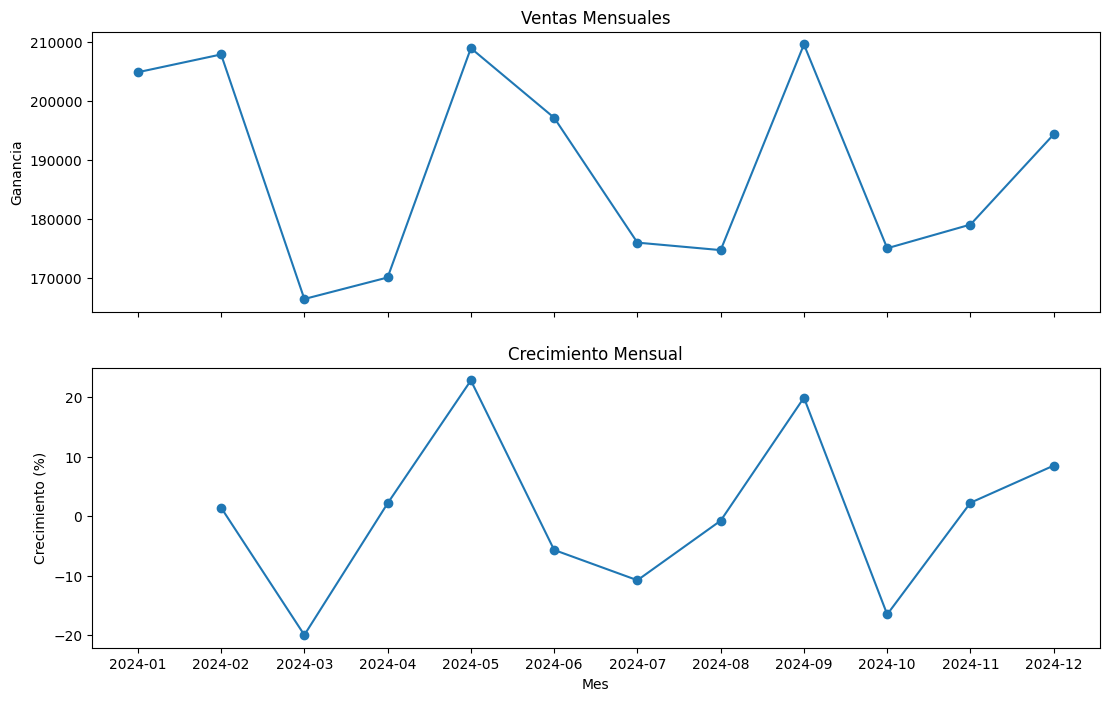

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, sharex= True, figsize=(13, 8))

venta_mensual.index = venta_mensual.index.astype(str)
crecimiento_mensual.index = crecimiento_mensual.index.astype(str)

ax[0].plot(venta_mensual, marker='o')
ax[0].set_title('Ventas Mensuales')
ax[0].set_ylabel('Ganancia')

ax[1].plot(crecimiento_mensual, marker='o')
ax[1].set_title('Crecimiento Mensual')
ax[1].set_xlabel('Mes')
ax[1].set_ylabel('Crecimiento (%)')

plt.show()

## Productos más vendidos

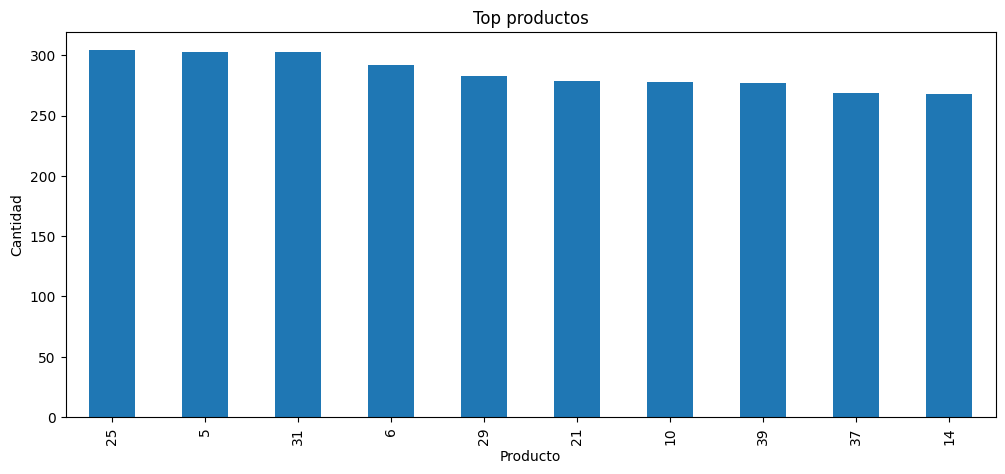

In [48]:
top_productos.plot(kind="bar", figsize=(12,5), title="Top productos")
plt.xlabel("Producto")
plt.ylabel("Cantidad")
plt.title("Top productos")
plt.show()

## Ventas por categorías

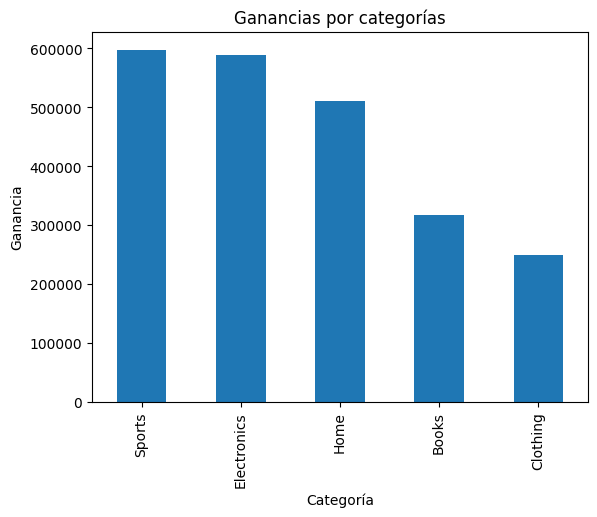

In [57]:
ventas_categoria.plot(kind="bar")
plt.title("Ganancias por categorías")
plt.xlabel("Categoría")
plt.ylabel("Ganancia")
plt.show()

## Gráficas de ciudades con ventas y ganancias

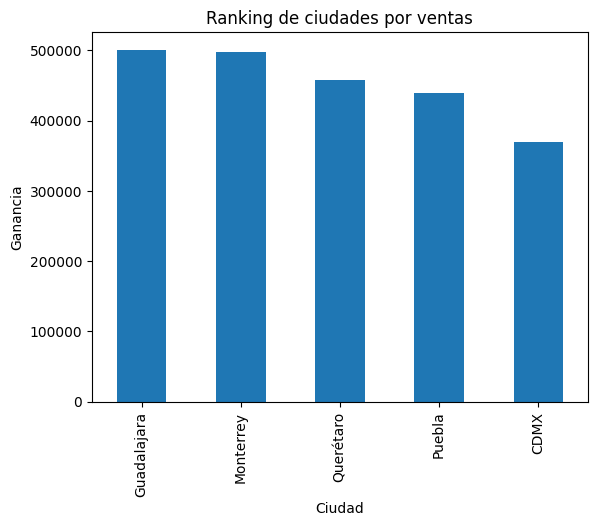

In [50]:
venta_por_ciudad.plot(kind="bar")
plt.title("Ranking de ciudades por ventas")
plt.ylabel("Ganancia")
plt.show()

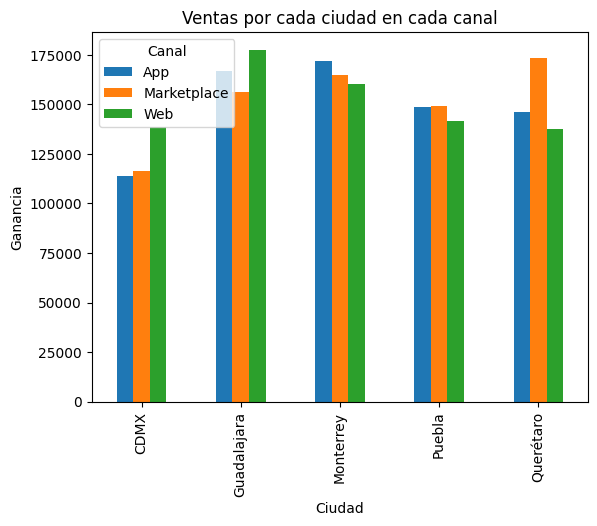

In [51]:
ventas_ciudad_canal.unstack().plot(kind="bar")
plt.title("Ventas por cada ciudad en cada canal")
plt.ylabel("Ganancia")
plt.show()

Esta gráfica es muy rica en información con respecto a información.

Notamos que Guadalajara es la ciudad con más ganancias y que el canal Web es donde se realiza más se realizan las mismas. En Queretaro donde el Marketplace lidera; y en Monterrey la App.

Sin embargo hay aquí también un punto importante que tocar y es la distribución de las ganancias en cada ciudad y canal. Esos puntos disparados en ciertos canales nos dice algo concreto en cada ciudad o de la estrategia comercial.

En Puebla y Monterrey se concentran mucho las ventas en los tres canales. En las ciudades donde predominan por mucho las ventas en un canal en específico hay que revisar del porqué de esto.

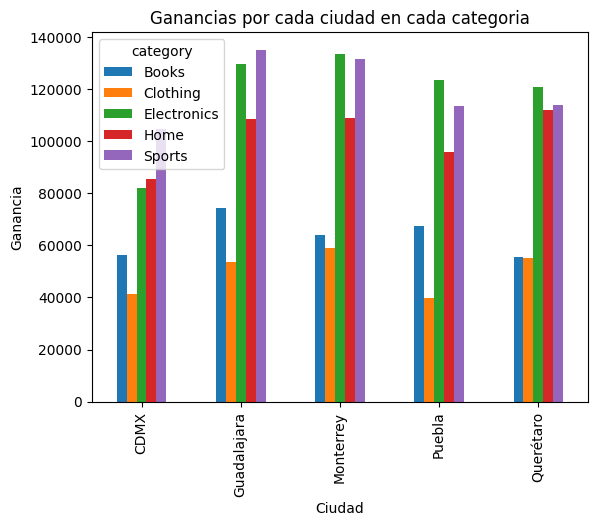

In [52]:
venta_city_category2.unstack().plot(kind="bar")
plt.title("Ganancias por cada ciudad en cada categoria")
plt.ylabel("Ganancia")
plt.show()

De esta gráfica podemos observar que son las categorias de Ropa y Libros los que menos ganancia dan. Las categorías con más ganancias fueron Deportes y Electrónica.

Es consistente con las ganancias en general, así como vimos en la tercera gráfica. Por lo que esa gráfica funciona bien como un reflejo de cada ciudad, ya que sigue el mismo patrón de ganancia por categoría.

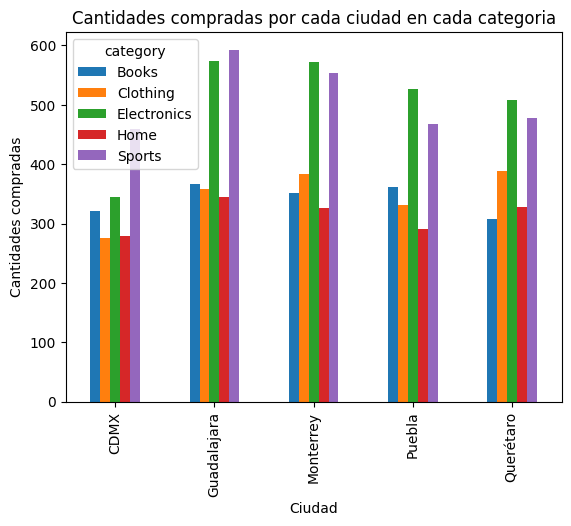

In [53]:
venta_city_category3.unstack().plot(kind="bar")
plt.title("Cantidades compradas por cada ciudad en cada categoria")
plt.ylabel("Cantidades compradas")
plt.show()

Aqui vemos un patrón importante en venta. La de Deportes es la que más vende en TODAS las ciudades, al igual que la de Electronica. Mientras que libros, ropa y elementos de casa son los que se compran de manera consistente pero en menor medida.

In [54]:
venta[['Precio de unidad','category']]

,Precio de unidad,category
0,113.23,Electronics
1,48.03,Books
2,387.67,Home
3,387.67,Home
4,193.16,Electronics
...,...,...
5031,66.79,Books
5032,212.66,Books
5033,118.38,Electronics
5034,137.53,Clothing


In [55]:
n= venta.groupby("category")["Precio de unidad"].max()
new=n.sort_values(ascending=False)
new

,Precio de unidad
category,
Home,478.82
Books,443.30
Electronics,428.38
Sports,422.21
Clothing,319.66


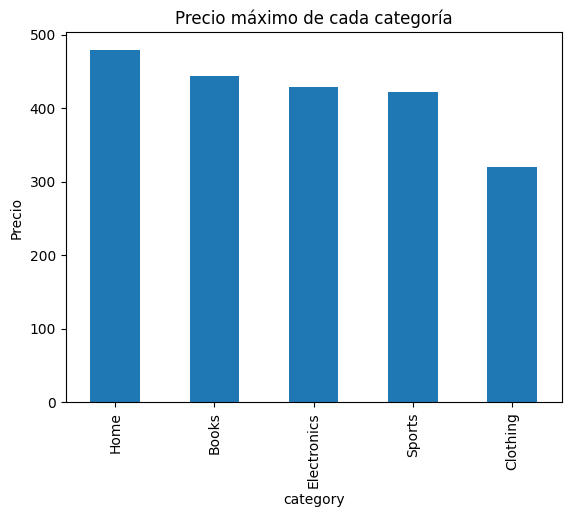

In [56]:
new.plot(kind="bar")
plt.title("Precio máximo de cada categoría")
plt.ylabel("Precio")
plt.show()

Los precios máximos de cada categoría no son tan distintos. Por lo que, que en cierta cetegoría se compre más o menos depende de la demanda, de la calidad del producto o de su marketing, no tanto del precio.

# Conclusión

📊 Conclusiones del Análisis

1. Tendencia de ventas

Se observó una variación en las ventas a lo largo del tiempo, con periodos de crecimiento y caída. Esto indica que el negocio no tiene un crecimiento constante, por lo que sería importante analizar factores externos como temporadas o campañas.

2. Crecimiento mensual irregular

El crecimiento mensual presenta valores positivos y negativos, lo que sugiere fluctuaciones en la demanda. Esto puede estar relacionado con estacionalidad o cambios en el comportamiento del cliente.

3. Baja tasa de conversión

La tasa de conversión (~0.94%) indica que una pequeña proporción de usuarios realiza compras, lo que representa una oportunidad clara de optimización en la experiencia de usuario o estrategias de marketing. Tal vez una mejora en la página web y/o campañas de lealtad/membresias/etc.

4. Ticket promedio y comportamiento de compra

El ticket promedio refleja el valor medio por pedido, y al analizarlo junto con los productos por orden, se observa que el ingreso depende tanto del número de pedidos como de la cantidad de productos adquiridos por compra.

5. Concentración de ventas por ciudad

Las ventas no están distribuidas de manera uniforme entre ciudades. Algunas concentran una mayor proporción del ingreso total, lo que indica dependencia geográfica y posibles oportunidades de expansión en otras regiones.

6. Diferencias entre categorías

Las categorías principales (como Sports y Electronics) presentan valores de ventas relativamente cercanos en 4 de 5 ciudades, lo que sugiere que no existe una categoría dominante clara, sino un portafolio equilibrado.

7. Variabilidad por canal

El análisis por canal muestra diferencias en el desempeño entre plataformas, lo que puede ayudar a enfocar estrategias específicas por canal.

### **Recomendaciones:**

Ventas cruzadas (cross-selling)
Creación de combos

Esto es especialmente con las categorías menos vendidas.

----------------------------------------------------

Este análisis demuestra la capacidad de transformar datos en insights mediante el uso de Python, pandas y técnicas de análisis de datos.